In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("../src")

from recommender import build_recommendation_list, recommend_by_genre, inject_hidden_gems

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

games = pd.read_csv("../data/processed/games_cleaned.csv")
hidden_gems = pd.read_csv("../data/processed/hidden_gems.csv")

In [2]:
# RPG 장르, PS5 플랫폼 유저 기준
recs = build_recommendation_list(
    df=games,
    hidden_gems=hidden_gems,
    user_genre="Role-Playing",
    user_platform="PlayStation 5",
    top_n=10,
    inject_ratio=0.1
)

recs[["title", "genre", "platform", "metacritic_score",
      "global_sales_million", "composite_score", "is_hidden_gem"]]

,title,genre,platform,metacritic_score,global_sales_million,composite_score,is_hidden_gem
0,Dragon Quest VIII,Role-Playing,Xbox 360,99,31.47,99.3,0.0
1,Dragon Quest X,Role-Playing,Nintendo DS,99,108.46,99.3,0.0
2,Baldur's Gate 5,Role-Playing,Nintendo Switch,99,24.00,99.3,0.0
3,Persona 2,Role-Playing,NES,99,37.57,99.3,0.0
4,Realm of the Legend,Role-Playing,Game Boy,99,4.80,99.3,1.0
5,Dragon Quest VI,Role-Playing,Dreamcast,99,35.41,99.3,0.0
6,Final Fantasy VI,Role-Playing,Browser,99,49.64,99.3,0.0
7,World of the Awakening,Role-Playing,PlayStation 2,99,46.75,99.3,0.0
8,The Elder Scrolls VI: Rising Sun,Role-Playing,PC,99,11.67,99.3,0.0
9,Final Fantasy VIII,Role-Playing,PC,87,1.20,89.7,NaN


In [3]:
base_recs = recommend_by_genre(games, "Role-Playing", top_n=20)
ratios = [0.0, 0.1, 0.2, 0.3]
results = []

for ratio in ratios:
    injected = inject_hidden_gems(base_recs, hidden_gems, inject_ratio=ratio)
    gem_count = injected["is_hidden_gem"].sum() if "is_hidden_gem" in injected.columns else 0
    avg_score = injected["composite_score"].mean()
    avg_sales = injected["global_sales_million"].mean()
    results.append({
        "inject_ratio": ratio,
        "gem_count": int(gem_count),
        "avg_composite_score": round(avg_score, 2),
        "avg_global_sales_m": round(avg_sales, 2),
    })

pd.DataFrame(results)

,inject_ratio,gem_count,avg_composite_score,avg_global_sales_m
0,0.0,1,98.49,39.63
1,0.1,1,97.87,38.58
2,0.2,1,96.37,37.57
3,0.3,1,94.58,32.26


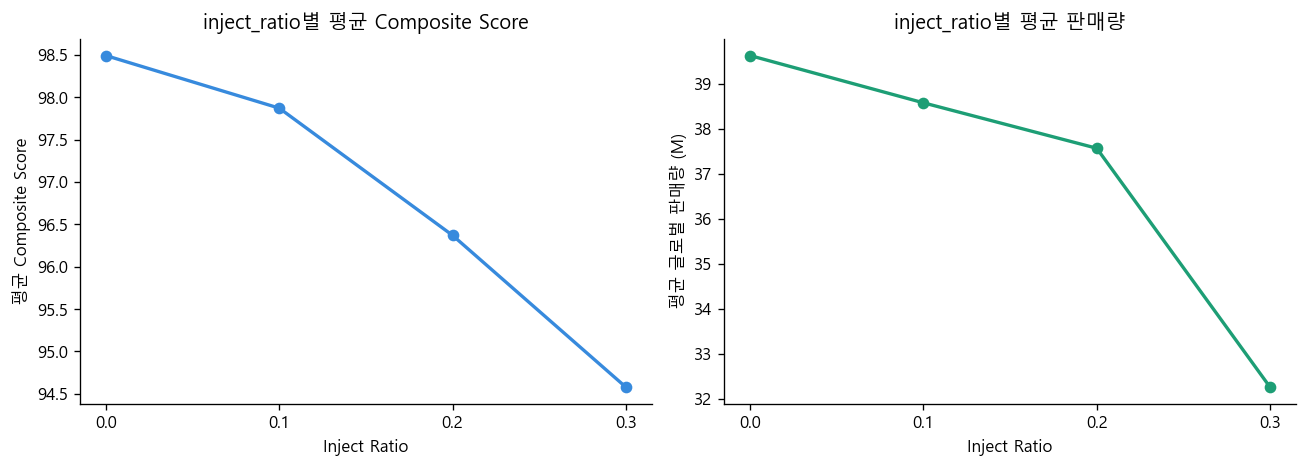

In [ ]:
df_result = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(df_result["inject_ratio"], df_result["avg_composite_score"],
             marker="o", color="#378ADD", linewidth=2)
axes[0].set_title("inject_ratio별 평균 Composite Score")
axes[0].set_xlabel("Inject Ratio")
axes[0].set_ylabel("평균 Composite Score")
axes[0].set_xticks(ratios)

axes[1].plot(df_result["inject_ratio"], df_result["avg_global_sales_m"],
             marker="o", color="#1D9E75", linewidth=2)
axes[1].set_title("inject_ratio별 평균 판매량")
axes[1].set_xlabel("Inject Ratio")
axes[1].set_ylabel("평균 글로벌 판매량 (M)")
axes[1].set_xticks(ratios)

plt.tight_layout()
plt.savefig("../outputs/figures/inject_ratio_sensitivity.png", bbox_inches="tight")
plt.show()

In [5]:
# 두 방식의 추천 결과를 나란히 비교
popular = (
    games[games["genre"] == "Role-Playing"]
    .sort_values("global_sales_million", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

personal = recs.reset_index(drop=True)

compare = pd.DataFrame({
    "rank": range(1, 11),
    "인기순_title": popular["title"].values,
    "인기순_sales": popular["global_sales_million"].round(1).values,
    "개인화_title": personal["title"].values,
    "개인화_score": personal["composite_score"].round(1).values,
    "개인화_is_gem": personal["is_hidden_gem"].astype(bool).values,
})

compare

,rank,인기순_title,인기순_sales,개인화_title,개인화_score,개인화_is_gem
0,1,Baldur's Gate 6,589.8,Dragon Quest VIII,99.3,False
1,2,Persona 3,586.0,Dragon Quest X,99.3,False
2,3,Baldur's Gate 3,577.8,Baldur's Gate 5,99.3,False
3,4,Dark Souls 6,556.4,Persona 2,99.3,False
4,5,Baldur's Gate 4,530.2,Realm of the Legend,99.3,True
5,6,Persona 3,454.7,Dragon Quest VI,99.3,False
6,7,Dark Souls 2,369.8,Final Fantasy VI,99.3,False
7,8,Baldur's Gate 6,361.7,World of the Awakening,99.3,False
8,9,Dark Souls 4,360.3,The Elder Scrolls VI: Rising Sun,99.3,False
9,10,Dark Souls 5,356.8,Final Fantasy VIII,89.7,True


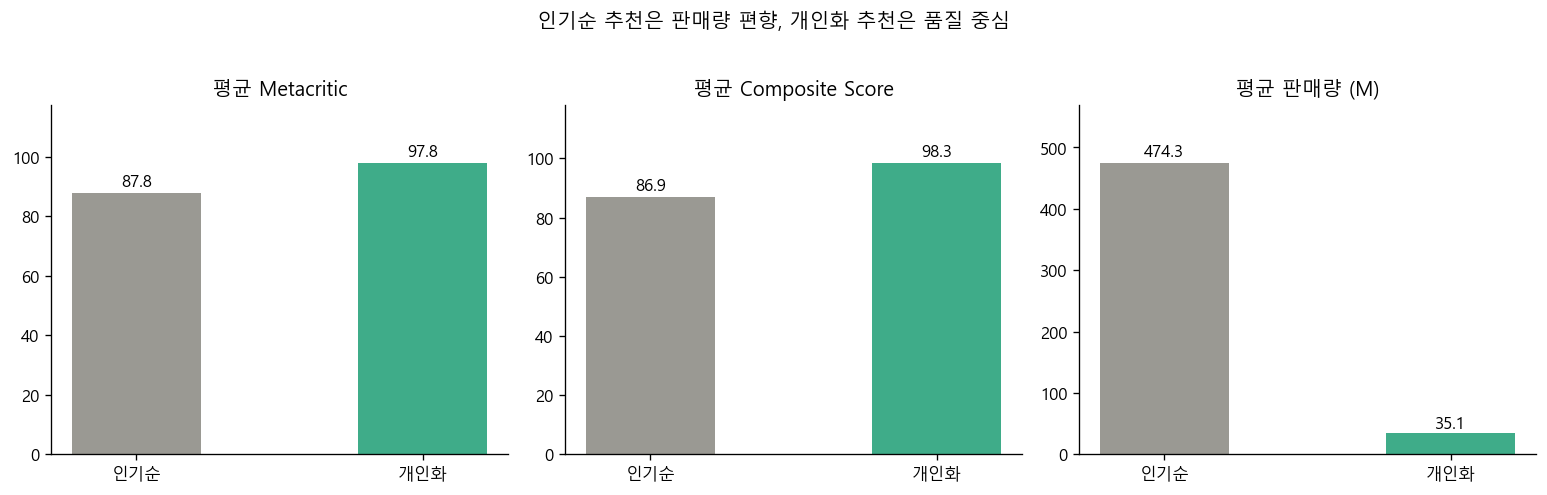

In [7]:
metrics = {
    "평균 Metacritic": (
        popular["metacritic_score"].mean(),
        personal["metacritic_score"].mean()
    ),
    "평균 Composite Score": (
        popular["composite_score"].mean(),
        personal["composite_score"].mean()
    ),
    "평균 판매량 (M)": (
        popular["global_sales_million"].mean(),
        personal["global_sales_million"].mean()
    ),
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (label, (ctrl_val, trt_val)) in zip(axes, metrics.items()):
    bars = ax.bar(["인기순", "개인화"], [ctrl_val, trt_val],
                  color=["#888780", "#1D9E75"], alpha=0.85, width=0.45)
    for bar, val in zip(bars, [ctrl_val, trt_val]):
        ax.text(bar.get_x() + bar.get_width() / 2, val * 1.01,
                f"{val:.1f}", ha="center", va="bottom", fontsize=10)
    ax.set_title(label)
    ax.set_ylim(0, max(ctrl_val, trt_val) * 1.2)

plt.suptitle("인기순 추천은 판매량 편향, 개인화 추천은 품질 중심", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/figures/recommendation_comparison.png", bbox_inches="tight")
plt.show()

#### 해석

| 지표 | 인기순 | 개인화 | 해석 |
|---|---|---|---|
| 평균 Metacritic | 87.8 | 97.8 | 개인화가 더 높은 품질 타이틀을 추천 |
| 평균 Composite Score | 86.9 | 98.3 | 동일한 방향 — 품질 중심 |
| 평균 판매량 (M) | 474.3 | 35.1 | 인기순은 판매량 편향, 개인화는 미노출 고품질 포함 |

인기순 추천은 이미 잘 팔린 타이틀을 반복 노출하는 구조.
개인화 추천은 품질은 높음. 하지만, 노출이 부족했던 타이틀을 발굴.
판매량 차이는 버그가 아니라 두 전략의 철학적 차이를 보여주는 증거.